In [1]:

# Import the required library
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Display dataset information
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


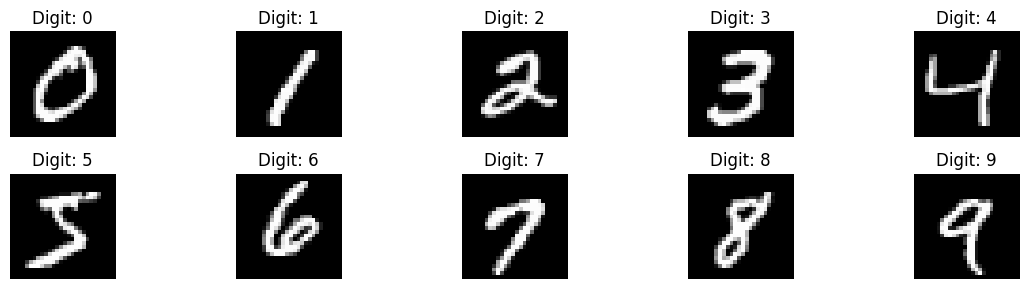

In [3]:

# Display one example of each digit from 0 to 9
plt.figure(figsize=(12, 3))

for digit in range(10):
    # Find the first image of this digit
    index = np.where(y_train == digit)[0][0]

    plt.subplot(2, 5, digit + 1)
    plt.imshow(X_train[index], cmap="gray")
    plt.title(f"Digit: {digit}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:

# Normalize pixel values to the range 0 to 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Check the new pixel value range
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

# Check the shape of the images
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [6]:

# Build the neural network

model = tf.keras.Sequential([
    # Define the input shape
    tf.keras.layers.Input(shape=(28, 28)),

    # Convert each image into 784 values
    tf.keras.layers.Flatten(),

    # Hidden layer with 128 neurons
    tf.keras.layers.Dense(128, activation="relu"),

    # Output layer with 10 neurons
    tf.keras.layers.Dense(10, activation="softmax")
])

# Display the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

# Compile the neural network

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:

# Train the neural network

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9198 - loss: 0.2797 - val_accuracy: 0.9657 - val_loss: 0.1243
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9636 - loss: 0.1230 - val_accuracy: 0.9713 - val_loss: 0.1022
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9747 - loss: 0.0838 - val_accuracy: 0.9762 - val_loss: 0.0816
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9809 - loss: 0.0619 - val_accuracy: 0.9770 - val_loss: 0.0829
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9844 - loss: 0.0491 - val_accuracy: 0.9807 - val_loss: 0.0767


In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0794
Test Loss: 0.07938516139984131
Test Accuracy: 97.50000238418579 %


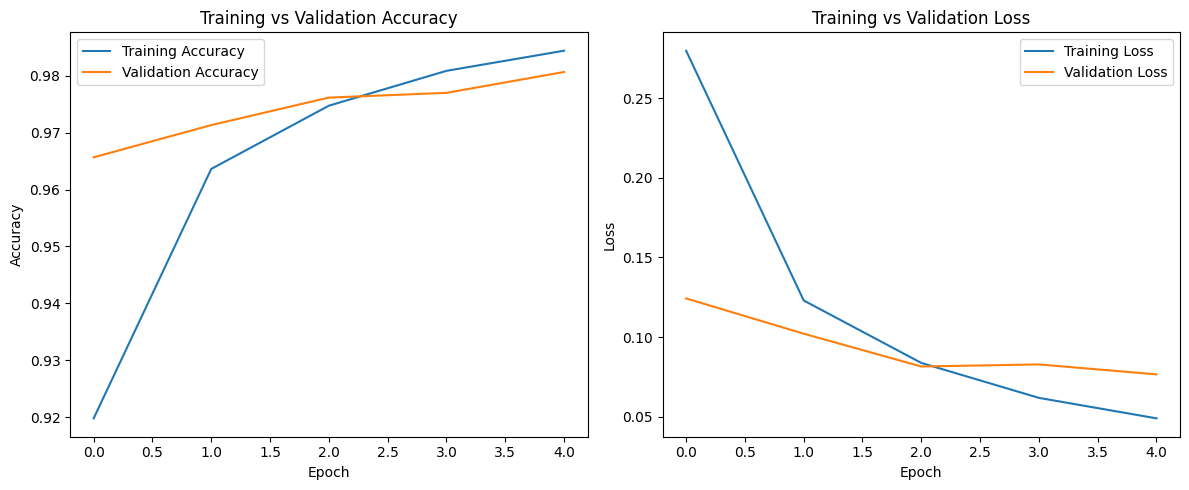

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


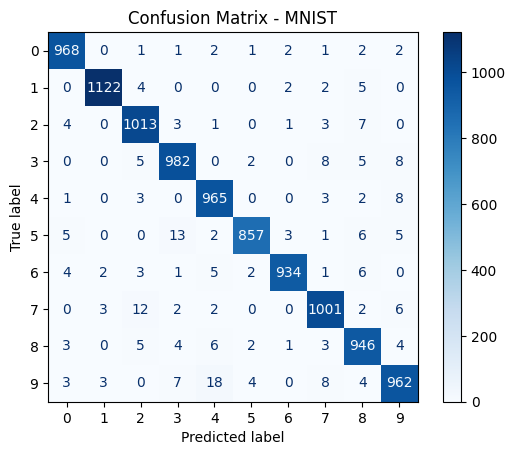

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the model
y_pred = model.predict(X_test)

# Convert probabilities into predicted digit labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - MNIST")
plt.show()

In [12]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

experiment_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_history = experiment_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9117 - loss: 0.3129 - val_accuracy: 0.9607 - val_loss: 0.1425
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9568 - loss: 0.1478 - val_accuracy: 0.9672 - val_loss: 0.1158
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9686 - loss: 0.1085 - val_accuracy: 0.9717 - val_loss: 0.1007
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9743 - loss: 0.0854 - val_accuracy: 0.9742 - val_loss: 0.0929
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9793 - loss: 0.0692 - val_accuracy: 0.9757 - val_loss: 0.0899


In [14]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    X_test, y_test
)

print("Experiment Test Loss:", experiment_loss)
print("Experiment Test Accuracy:", experiment_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9715 - loss: 0.0918
Experiment Test Loss: 0.09176382422447205
Experiment Test Accuracy: 97.14999794960022 %


In [15]:
print("MODEL COMPARISON")
print("-------------------------")
print("Original Model (128 neurons):")
print("Test Accuracy:", test_accuracy * 100, "%")
print("Test Loss:", test_loss)

print("\nModified Model (64 neurons):")
print("Test Accuracy:", experiment_accuracy * 100, "%")
print("Test Loss:", experiment_loss)

MODEL COMPARISON
-------------------------
Original Model (128 neurons):
Test Accuracy: 97.50000238418579 %
Test Loss: 0.07938516139984131

Modified Model (64 neurons):
Test Accuracy: 97.14999794960022 %
Test Loss: 0.09176382422447205


## Experiment: Effect of Hidden Layer Neurons

### Objective

To investigate how changing the number of neurons in the hidden layer affects the performance of a neural network on the MNIST dataset.

### Experiment Setup

* **Baseline model:** 128 hidden neurons
* **Modified model:** 64 hidden neurons
* **Activation functions:** ReLU for the hidden layer and Softmax for the output layer
* **Optimizer:** Adam
* **Epochs:** 5
* **Batch size:** 32

### Results

The two models were evaluated using test accuracy and test loss. The results are compared in the output of the model comparison cell above.

### Conclusion

Changing the number of hidden neurons changes the model's capacity to learn patterns. The comparison helps us understand how the number of neurons affects classification performance.


## Experiment Results and Analysis

| Metric        | Baseline (128 neurons) | Modified (64 neurons) |
| ------------- | ---------------------: | --------------------: |
| Test Accuracy |                 97.50% |                97.15% |
| Test Loss     |                 0.0794 |                0.0918 |

### Analysis

The baseline model with 128 hidden neurons achieved a test accuracy of 97.50% and a test loss of 0.0794.

The modified model with 64 hidden neurons achieved a test accuracy of 97.15% and a test loss of 0.0918.

The baseline model performed slightly better in this experiment, with 0.35 percentage points higher test accuracy and lower test loss.

### Conclusion

Reducing the number of hidden neurons from 128 to 64 resulted in a small decrease in test accuracy and an increase in test loss. This experiment demonstrates how changing the hidden layer size can affect neural network performance.


## Conclusion

In this project, I built a neural network to classify handwritten digits from the MNIST dataset.

The project involved loading and exploring the dataset, normalizing pixel values, building and training a neural network using TensorFlow and Keras, evaluating its performance, and visualizing the results using accuracy and loss curves and a confusion matrix.

I also experimented with changing the number of hidden neurons and compared the performance of the baseline and modified models.

This project helped me understand the basic workflow of a neural network classification task, including data preprocessing, model training, evaluation, and experimentation.
